<a href="https://colab.research.google.com/github/AristidesAntonioOrellanaZelaya/InnovaSoft/blob/main/Notebooks/Casopractico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ACTIVIDAD 1

In [1]:
import pandas as pd

In [13]:
url = "https://raw.githubusercontent.com/AristidesAntonioOrellanaZelaya/InnovaSoft/refs/heads/main/Data/Prestige_modificado.csv"
df = pd.read_csv(url,sep=';')
df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [15]:
print(df.shape)

(102, 7)


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [17]:
print(df.isnull().sum())

occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [18]:
print(df.duplicated().sum())

0


In [20]:
df.describe()

,education,income,women,prestige,census,type_num
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,10.738039,6797.901961,28.979020,46.833333,5401.774510,1.843137
std,2.728444,4245.922227,31.724931,17.204486,2644.993215,0.817447
min,6.380000,611.000000,0.000000,14.800000,1113.000000,0.000000
25%,8.445000,4106.000000,3.592500,35.225000,3120.500000,1.000000
50%,10.540000,5930.500000,13.600000,43.600000,5135.000000,2.000000
75%,12.647500,8187.250000,52.202500,59.275000,8312.500000,2.000000
max,15.970000,25879.000000,97.510000,87.200000,9517.000000,3.000000


ACTIVIDAD 2

In [21]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000


In [22]:
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


ACTIVIDAD 3

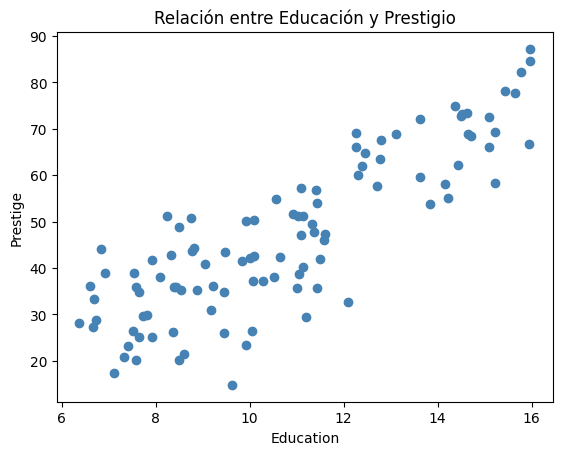

In [24]:
plt.figure()
plt.scatter(df['education'], df['prestige'], color='steelblue')
plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre Educación y Prestigio')
plt.show()

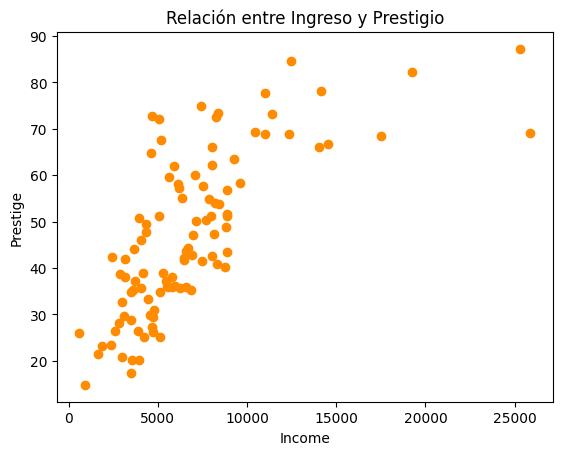

In [25]:
plt.figure()
plt.scatter(df['income'], df['prestige'], color='darkorange')
plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre Ingreso y Prestigio')
plt.show()

<Figure size 800x500 with 0 Axes>

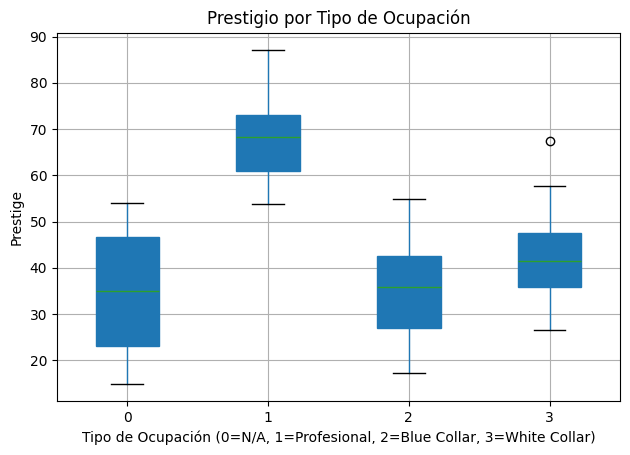

In [26]:

plt.figure(figsize=(8,5))
df.boxplot(column='prestige', by='type_num', patch_artist=True)
plt.title('Prestigio por Tipo de Ocupación')
plt.suptitle('')
plt.xlabel('Tipo de Ocupación (0=N/A, 1=Profesional, 2=Blue Collar, 3=White Collar)')
plt.ylabel('Prestige')
plt.tight_layout()
plt.show()

ACTIVIDAD 4

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [28]:
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

In [29]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

In [30]:
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

In [31]:
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

In [32]:
print("=== CENTROIDES K=4 ===")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

=== CENTROIDES K=4 ===
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [33]:
print("\n=== CENTROIDES K=5 ===")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))


=== CENTROIDES K=5 ===
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


ACTIVIDAD 5

1.	¿Qué variables parecen tener mayor relación con el prestigio de una ocupación?

Las variables con mayor relación suelen ser Education e Income, ya que las ocupaciones con mayor nivel educativo y mejores salarios normalmente tienen más prestigio. El tipo de ocupación también influye. Sin embargo, correlación no significa causalidad.

2.	¿Cómo podría una empresa de software usar este tipo de análisis para valorar roles técnicos, gerenciales o de soporte?

Una empresa de software podría usar estos análisis para identificar qué perfiles tienen mayor valor dentro de la organización, mejorar salarios, planificar capacitaciones y fortalecer roles técnicos, gerenciales o de soporte según sus necesidades.


3.	¿Qué grupos de ocupaciones se identificaron y cómo podrían interpretarse?

Con el modelo de 5 clústeres se identificaron los siguientes perfiles:

Cluster 4: Elite profesional — alta educación, máximo ingreso y prestigio. Equivalente a roles senior o directivos en software.

Cluster 2: Profesionales educados — buen nivel educativo y prestigio alto. Corresponde a perfiles técnicos especializados.

Cluster 1: Blue collar masculino — educación e ingresos medios, prestigio moderado. Similar a roles operativos o de soporte técnico.

Cluster 0: Ocupaciones femeninas — ingresos bajos, prestigio medio. Sugiere posibles brechas de género en valoración.

Cluster 3: Bajo perfil — menor educación, ingresos y prestigio más bajos. Roles de entrada o sin especialización.




4.	¿Existen resultados que parezcan anómalos o difíciles de explicar?

Sí, algunas ocupaciones pueden tener altos ingresos pero bajo prestigio, o mucha educación con salarios moderados. También pueden influir factores sociales o históricos difíciles de medir solo con datos.

5.	¿Qué información adicional haría falta para tomar mejores decisiones?

Sería útil incluir experiencia laboral, certificaciones, desempeño, satisfacción laboral, habilidades tecnológicas y demanda del mercado. Esto permitiría realizar análisis más completos y precisos.